# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [223]:
# importar librerías

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [224]:
# cargar archivos


plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')



In [225]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [226]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [227]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [228]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [229]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [230]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [231]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [232]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [233]:
# cantidad de nulos para usage


print(usage.isna().sum())
print(usage.isna().mean())



id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
 
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  En la base de datos users_latam, hay poco mas de 400 valores nulos en la columna de city, un poco mas de 11%. Mientras que la columna churn_date llega a mas del 80%.
  En la base de datos usage, tenemos la columna date con un 0.125% de valores faltantes, duration con un 55% y lenght con 44%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Para la base de datos users_latam, en la columna de ciudad imputaria los valores nulos con "unkown" para no perder los datos y no afectar. Para churn_date usaria la funcion de pandas para transformarlo en formato date mas corto, y los errores los imputaria como "Activo" o NaD.
  Para la base de datos usage, la columna date se debe transformar a formato date y dejar los valores nulos como NaD. Y las columnas de duration y lenght se complementan, ya que las llamadas tienen duracion y los mensajes length, entonces los valores nulos se deben imputar cada uno con NaN.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [234]:
# explorar columnas numéricas de users
columnas_nusers = [["user_id","age"]]
for col in columnas_nusers :
    print(users[col].describe())
    

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  La columna user_id no tiene ningun valor extrano, son 4000 usuarios, empezando la cuenta en 10000 (valor minimo), y terminando en 13999 (valor maximo).
- La columna `age` ...
  La columna age si tiene un sentinel de -999 lo que hace que el promedio se desplace hacia la izquierda, por lo tanto este valor se debe corregir.

In [235]:
# explorar columnas numéricas de usage
columnas_nusage = [["user_id","duration","length"]]
for col in columnas_nusage :
    print(usage[col].describe())
    

            user_id      duration        length
count  40000.000000  17924.000000  22104.000000
mean   12002.405975      5.202237     52.127398
std     1157.279564      6.842701     56.611183
min    10000.000000      0.000000      0.000000
25%    10996.000000      1.437500     37.000000
50%    12013.000000      3.500000     50.000000
75%    13005.000000      6.990000     64.000000
max    13999.000000    120.000000   1490.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  La columna user_id no tiene ningun valor extrano, son 4000 usuarios, empezando la cuenta en 10000 (valor minimo), y terminando en 13999 (valor maximo).
- La columna `duration` ...
  La columna duration si tiene valores dentro de lo normal, con un posible outlier de 120 haciendo que el promedio sea mucho mayor que la mediana.
- La columna `length` no tiene valores negativos, sin embargo tiene un valor maximo muy grande, por lo que se debe revisar la posibilidad de cappear.

In [236]:
# explorar columnas categóricas de usersz
columnas_user = ['city', 'plan']

for col in columnas_user :
    print(users[col].unique())



['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
['Basico' 'Premium']


- La columna `city` tiene valores sentinels como "?" y nan
- La columna `plan` solo tiene dos valores, basico y premium

In [237]:
# explorar columna categórica de usage
usage['type'] # completa el código
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` tiene dos valores, call y text, segun lo esperado.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? se encontraron sentinels como "?" y nan
- ¿Qué acción tomarías? se debe estudiar si los sentinels tienen alguna relacion o tendencia o si son completamente al azar, de eso dependera el valor por el cual se deben reemplazar.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [238]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [239]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [240]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date` se encuentra un valor erroneo, ya que no deberian haber valores del ano 2026.

In [241]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date` se encutran valores del ano 2024 y nan.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos), primero solo se tienen datos de mensajes y llamadas del ano 2024. Adicionalmente, se tienen datos erroneos en la columna de date_reg, ya que no es posible tener fechas del ano 2026.
- ¿Qué harías con ellas? las fechas invalidas se deben tratar como NaT.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [242]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] =  users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [243]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?","NA")

# Verificar cambios
users['city'].unique()

array(['Medellín', 'NA', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [244]:

# Marcar fechas futuras como NA para reg_date
users['reg_date_clean']=users['reg_date'].dt.date
users.loc[users['reg_date_clean']>pd.to_datetime('2024-12-31').date(),'reg_date_clean']="NA"

# Verificar cambios
years = [x.year for x in users['reg_date_clean'] if x != "NA"]
unique_years = sorted(set(years))
print("Años únicos después de la limpieza:", unique_years)

Años únicos después de la limpieza: [2022, 2023, 2024]


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [245]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [246]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos si tienen relacion, como se ve en duracion todos los valores nulos son del tipo de texto, ya que la metrica para medir el texto en el estudio no es el tiemp si no la longitud del texto.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [247]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'duration':['count','sum'],'length':'count'}).reset_index()

# observar resultado
usage_agg.head(3)

user_id duration        length
             count    sum  count
0   10000        3  23.70      7
1   10001       10  33.18      5
2   10002        2  10.74      5

In [248]:
# Renombrar columnas
usage_agg.columns = ['_'.join(col).strip('_') for col in usage_agg.columns]
usage_agg = usage_agg.rename(columns={('duration_count'):'cant_llamadas',('duration_sum'):'cant_minutos_llamada',('length_count'):'cant_mensajes'})
# observar resultado
usage_agg.head(3)

,user_id,cant_llamadas,cant_minutos_llamada,cant_mensajes
0,10000,3,23.70,7
1,10001,10,33.18,5
2,10002,2,10.74,5


In [249]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_clean,cant_llamadas,cant_minutos_llamada,cant_mensajes
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022-01-01,3.0,23.70,7.0
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022-01-01,10.0,33.18,5.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022-01-01,2.0,10.74,5.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022-01-01,3.0,8.99,11.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022-01-02,3.0,8.01,4.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [250]:
# Resumen estadístico de las columnas numéricas
columnas=[['cant_llamadas','cant_minutos_llamada','cant_mensajes']]
for col in columnas:
    print(user_profile[col].describe())

       cant_llamadas  cant_minutos_llamada  cant_mensajes
count    3999.000000           3999.000000    3999.000000
mean        4.482121             23.317054       5.527382
std         2.145092             18.168095       2.358383
min         0.000000              0.000000       0.000000
25%         3.000000             11.120000       4.000000
50%         4.000000             19.780000       5.000000
75%         6.000000             31.415000       7.000000
max        15.000000            155.690000      17.000000


In [251]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize='true')

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

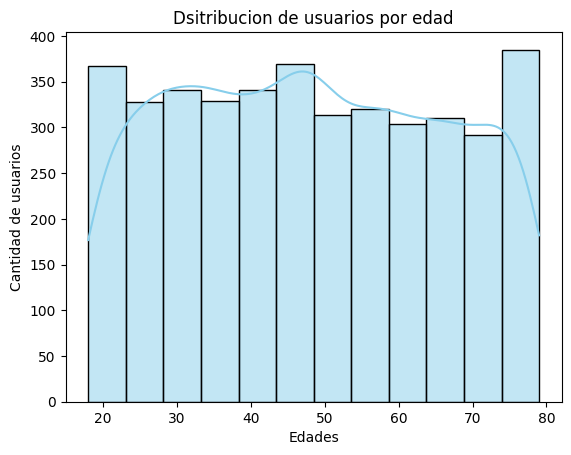

In [252]:
# Histograma para visualizar la edad (age)

sns.histplot(user_profile['age'],bins=12,color='skyblue',kde=True)
plt.xlabel('Edades')
plt.ylabel('Cantidad de usuarios')
plt.title('Dsitribucion de usuarios por edad')
plt.show()


💡Insights: 
La distribucion de usuarios por edad es una distribucion normal, uniforme, donde no se presentan sesgos o datos alejados, con un pequeno pico entre 40 y 50, por lo que indica una forma de campana, lo que nos diria que la media y mediana deben ser valores cercanos.

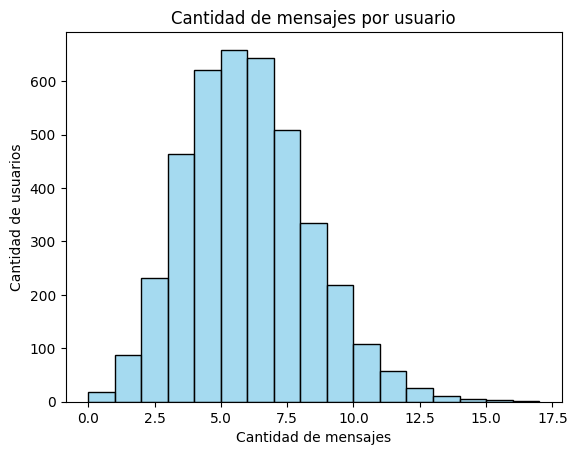

In [253]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'],bins=17,color='skyblue')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de mensajes por usuario')
plt.show()

💡Insights: 
- En el histograma de cantidad de mensajes por usuario se ve una grafica con un ligero sesgo hacia a la derecha, ya que el promedio de mensajes esta alrededor de 5 y 7 mensajes por usuario, pero tenemos valor maximo de 17, ubicando la mediana un poco mayor al promedio. Adicionalmente, no se ven valores erroneos o negativos.

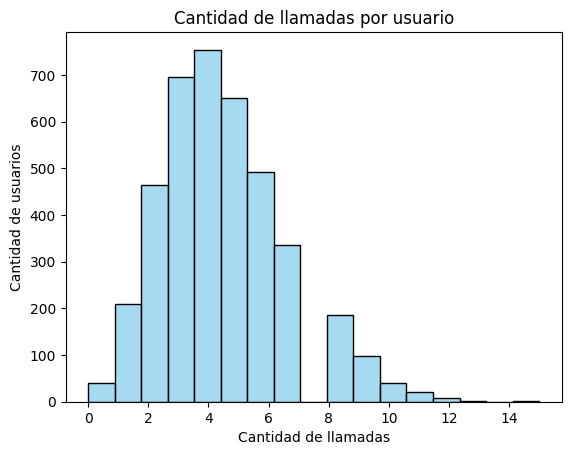

In [254]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile['cant_llamadas'],bins=17,color='skyblue')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de llamadas por usuario')
plt.show()

💡Insights: 
- Distribución muy parecida a la de cantidad de mensajes por usuario, misma tendencia y distribucion. Sin embargo se ve una anomalia al no tener usuarios con 7 llamadas, por lo que se debe estudiar si es un error del sistema o es real.

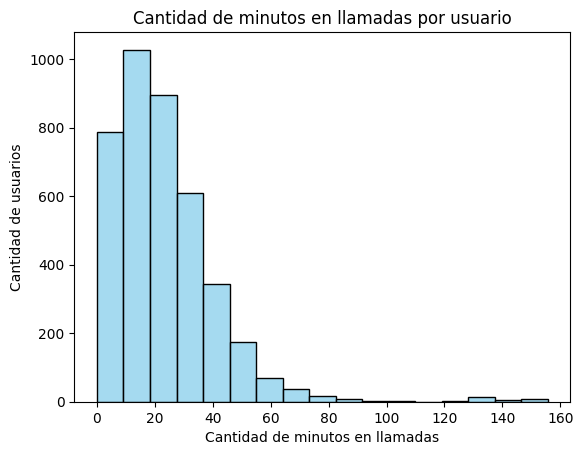

In [255]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'],bins=17,color='skyblue')
plt.xlabel('Cantidad de minutos en llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Cantidad de minutos en llamadas por usuario')
plt.show()

💡Insights: 
- La distribucion de los datos de la tabla anterior muestran un sesgo ha la derecha, con valores cercanos a los 160, mucho mayor a la concentracion promedio de toda la base de datos, por lo que hace mas probable la presencia de outliers.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

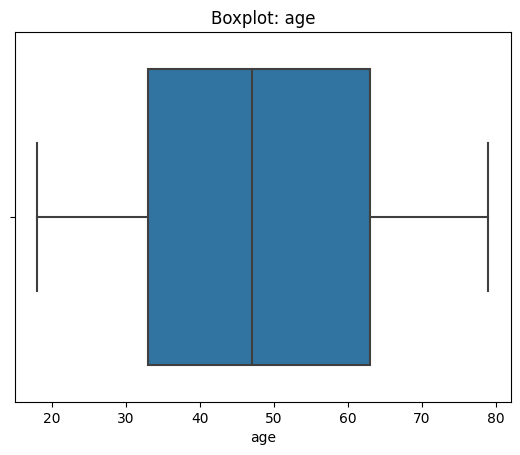

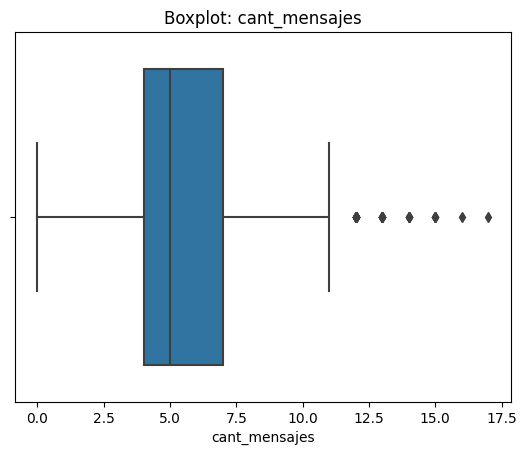

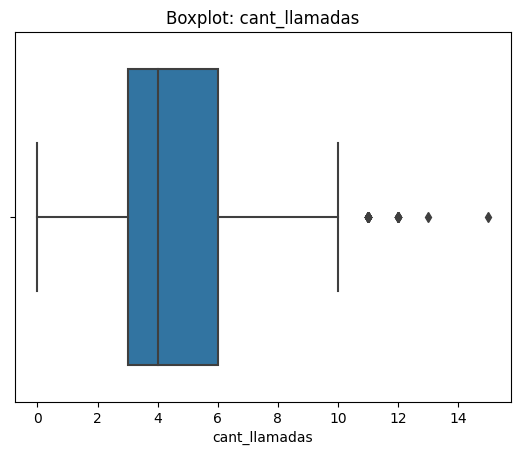

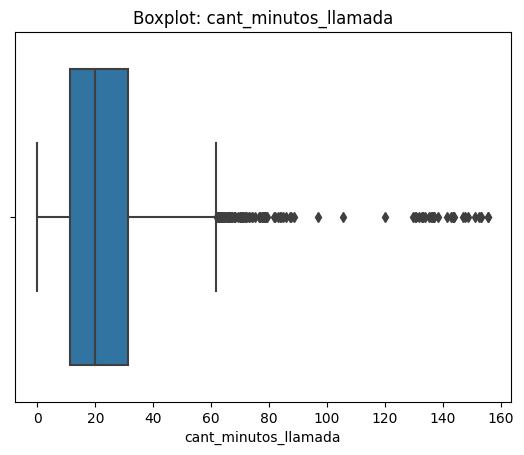

In [256]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age presenta outliers.
- cant_mensajes presenta pocos outliers 
- cant_llamadas presemta pocos outliers
- cant_minutos_llamada tiene mas outliers que las demas variables, con valores grandes a la derecha.b

In [257]:
# Calcular límites con el método IQR
columnas_limites = ['cant_llamadas','cant_minutos_llamada','cant_mensajes']
for col in columnas_limites:
    Q3 = user_profile[col].quantile(0.75)
    Q1 = user_profile[col].quantile(0.25)
    IQR = Q3 - Q1
    limite_inf = Q1 -1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    #print(f'limite_inferior {col}:',limite_inf)
    print(f'limite_superior {col}:',limite_sup)

limite_superior cant_llamadas: 10.5
limite_superior cant_minutos_llamada: 61.8575
limite_superior cant_mensajes: 11.5


In [258]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_llamadas,cant_minutos_llamada,cant_mensajes
count,3999.000000,3999.000000,3999.000000
mean,4.482121,23.317054,5.527382
std,2.145092,18.168095,2.358383
min,0.000000,0.000000,0.000000
25%,3.000000,11.120000,4.000000
50%,4.000000,19.780000,5.000000
75%,6.000000,31.415000,7.000000
max,15.000000,155.690000,17.000000


💡Insights: 
- cant_mensajes: Se deben mantener, son outliers segun el metodo del IQR, pero estos datos pueden ser reales y representar casos particulares de clientes de alto consumo a los que puede ser ofrecidos mejoras en sus planes.
- cant_llamadas: Se deben mantener, son outliers segun el metodo del IQR, pero estos datos pueden ser reales y representar casos particulares de clientes de alto consumo a los que puede ser ofrecidos mejoras en sus planes.
- cant_minutos_llamada: Se deben mantener, son outliers segun el metodo del IQR, pero estos datos pueden ser reales y representar casos particulares de clientes de alto consumo a los que puede ser ofrecidos mejoras en sus planes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [259]:
# Crear columna grupo_uso

# Crear la clasificación paso a paso
conditions = [
    (user_profile['cant_llamadas'] >= 10) | (user_profile['cant_mensajes'] >= 10),
    (user_profile['cant_llamadas'] >= 5) | (user_profile['cant_mensajes'] >= 5)
]

choices = ['Alto_uso', 'Uso_medio']

user_profile['grupo_uso'] = np.select(conditions, choices, default='Bajo_uso')

In [260]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_clean,cant_llamadas,cant_minutos_llamada,cant_mensajes,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022-01-01,3.0,23.70,7.0,Uso_medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022-01-01,10.0,33.18,5.0,Alto_uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022-01-01,2.0,10.74,5.0,Uso_medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022-01-01,3.0,8.99,11.0,Alto_uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022-01-02,3.0,8.01,4.0,Bajo_uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [261]:
# Crear columna grupo_edad
# Crear la clasificación paso a paso
conditions = [
    (user_profile['age'] < 30),
    (user_profile['age'] <= 60)
]

choices = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(conditions, choices, default='Adulto_Mayor')

In [262]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_clean,cant_llamadas,cant_minutos_llamada,cant_mensajes,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022-01-01,3.0,23.70,7.0,Uso_medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,2022-01-01,10.0,33.18,5.0,Alto_uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022-01-01,2.0,10.74,5.0,Uso_medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022-01-01,3.0,8.99,11.0,Alto_uso,Adulto_Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022-01-02,3.0,8.01,4.0,Bajo_uso,Adulto_Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

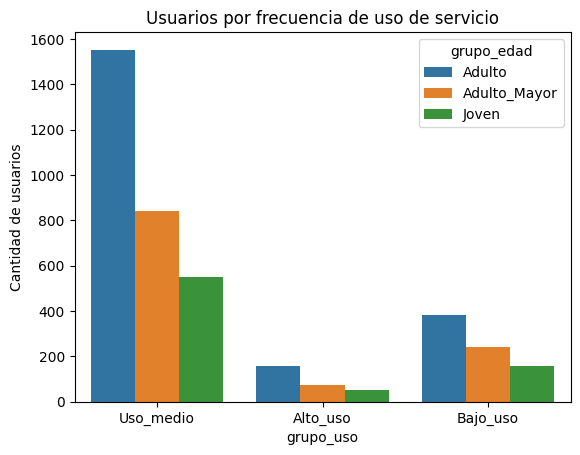

In [268]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',hue='grupo_edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por frecuencia de uso de servicio')
plt.show()


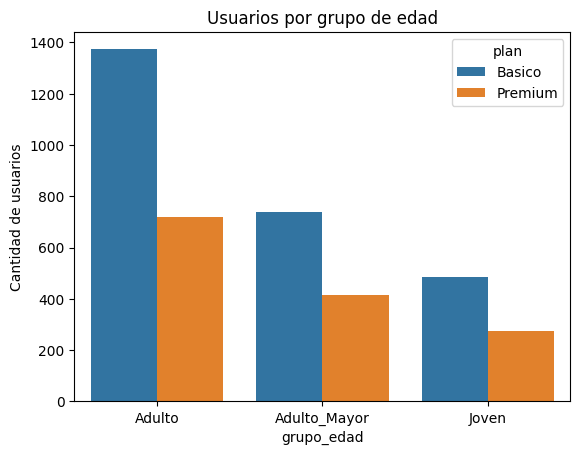

In [267]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',hue='plan')
plt.ylabel('Cantidad de usuarios')
plt.title('Usuarios por grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
-De las dos bases de datos grandes como “users” y “usage”, se tenían algunos problemas con los datos originalmente, la base de datos users tenia datos nulos de ciudades, lo cual representaba casi un 12% del total. Pero estos datos faltantes son CAR, y al no tener ninguna relación con otro parámetro se reempalzaron por el texto ‘NA’.
-Y usage, tenía una gran cantidad de datos nulos en las columnas de duration y lenght, con un 55% y 44% respectivamente, sin embargo, esto se debía a que la columna de duration solo tenia datos de usuarios que hacían llamadas (ya que es solamente con este parámetro que se mide el uso de llamadas), y lenght por su parte es el parámetro usado para medir el uso del servicio de mensaje de texto. 



🔍 **Segmentos por Edad**
-La distribución de edades en los clientes es muy variada, se clasificaron según su edad en tres grupos, jóvenes (menos de 30), adultos (entre 30 y 60) y adultos mayores (más de 60), sin embargo, la mayor concentración de usuarios esta en adultos entre 30 y 60 años. 
-Según su uso los clasificamos en tres grupos, de alto uso (mas de 10 mensajes o llamadas), uso medio (mas de 5 mensajes o llamadas) y bajo uso (menos de 5 mensajes o llamadas 



📊 **Segmentos por Nivel de Uso**
El grupo mas importante son los adultos, ya que, siendo el grupo más grande en cantidad de usuarios tanto de planes básicos como premium, por lo que es el grupo que mas aporta a los ingresos por subscripciones. 


➡️ Esto sugiere que ...


💡 **Recomendaciones**

Se encontraron outliers pocos outliers en cantidad de mensajes y llamadas por usuario, adicionalmente, en cantidad de minutos si se encuentran más, lo que implica que en estos momentos el servicio de llamadas es el mas popular y que además cuenta con mas usuarios dispuestos a pagar por un servicio premium para poder tener más minutos disponibles. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`